## Building intuition for Text summarization using LLM


In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

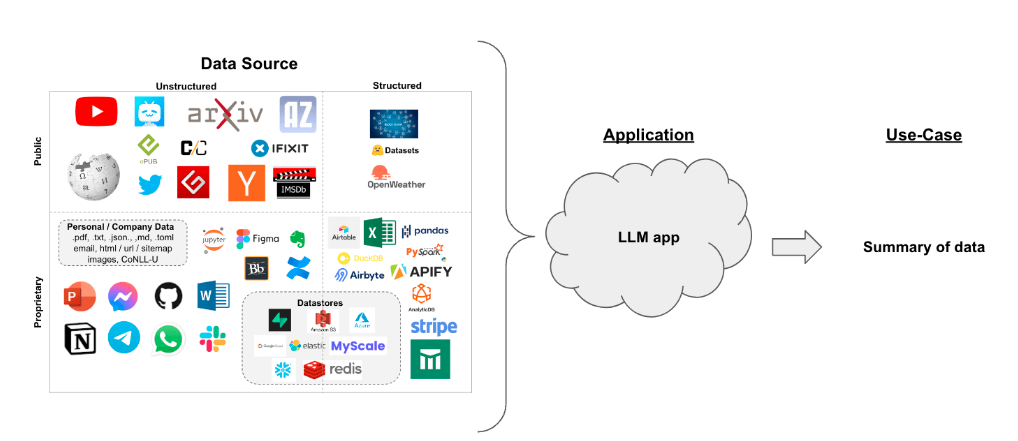

In [5]:
from langchain_groq import ChatGroq
api_key  = os.getenv("GROQ_API_KEY")
llm = ChatGroq(groq_api_key=api_key, model="Llama3-8b-8192")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001DC09DCA470>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DC09DCB8E0>, model_name='Llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
from langchain.schema import (
    AIMessage,
    HumanMessage, SystemMessage
)

In [7]:
speech = """
I am happy to join with you today in what will go down in history as the greatest demonstration for freedom in the history of our nation.

Five score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation Proclamation. This momentous decree came as a great beacon light of hope to millions of Negro slaves who had been seared in the flames of withering injustice. It came as a joyous daybreak to end the long night of their captivity.

But one hundred years later, the Negro still is not free. One hundred years later, the life of the Negro is still sadly crippled by the manacles of segregation and the chains of discrimination. One hundred years later, the Negro lives on a lonely island of poverty in the midst of a vast ocean of material prosperity. One hundred years later, the Negro is still languished in the corners of American society and finds himself an exile in his own land. And so we've come here today to dramatize a shameful condition.

In a sense we've come to our nation's capital to cash a check. When the architects of our republic wrote the magnificent words of the Constitution and the Declaration of Independence, they were signing a promissory note to which every American was to fall heir. This note was a promise that all men, yes, black men as well as white men, would be guaranteed the "unalienable Rights" of "Life, Liberty and the pursuit of Happiness." It is obvious today that America has defaulted on this promissory note, insofar as her citizens of color are concerned. Instead of honoring this sacred obligation, America has given the Negro people a bad check, a check which has come back marked "insufficient funds."

But we refuse to believe that the bank of justice is bankrupt. We refuse to believe that there are insufficient funds in the great vaults of opportunity of this nation. And so, we've come to cash this check, a check that will give us upon demand the riches of freedom and the security of justice.

We have also come to this hallowed spot to remind America of the fierce urgency of Now. This is no time to engage in the luxury of cooling off or to take the tranquilizing drug of gradualism. Now is the time to make real the promises of democracy. Now is the time to rise from the dark and desolate valley of segregation to the sunlit path of racial justice. Now is the time to lift our nation from the quicksands of racial injustice to the solid rock of brotherhood. Now is the time to make justice a reality for all of God's children.

It would be fatal for the nation to overlook the urgency of the moment. This sweltering summer of the Negro's legitimate discontent will not pass until there is an invigorating autumn of freedom and equality. Nineteen sixty-three is not an end, but a beginning. And those who hope that the Negro needed to blow off steam and will now be content will have a rude awakening if the nation returns to business as usual. And there will be neither rest nor tranquility in America until the Negro is granted his citizenship rights. The whirlwinds of revolt will continue to shake the foundations of our nation until the bright day of justice emerges.



But there is something that I must say to my people, who stand on the warm threshold which leads into the palace of justice: In the process of gaining our rightful place, we must not be guilty of wrongful deeds. Let us not seek to satisfy our thirst for freedom by drinking from the cup of bitterness and hatred. We must forever conduct our struggle on the high plane of dignity and discipline. We must not allow our creative protest to degenerate into physical violence. Again and again, we must rise to the majestic heights of meeting physical force with soul force.

The marvelous new militancy which has engulfed the Negro community must not lead us to a distrust of all white people, for many of our white brothers, as evidenced by their presence here today, have come to realize that their destiny is tied up with our destiny. And they have come to realize that their freedom is inextricably bound to our freedom.

We cannot walk alone.

And as we walk, we must make the pledge that we shall always march ahead.

We cannot turn back.

There are those who are asking the devotees of civil rights, "When will you be satisfied?" We can never be satisfied as long as the Negro is the victim of the unspeakable horrors of police brutality. We can never be satisfied as long as our bodies, heavy with the fatigue of travel, cannot gain lodging in the motels of the highways and the hotels of the cities. **We cannot be satisfied as long as the negro's basic mobility is from a smaller ghetto to a larger one. We can never be satisfied as long as our children are stripped of their self-hood and robbed of their dignity by signs stating: "For Whites Only."** We cannot be satisfied as long as a Negro in Mississippi cannot vote and a Negro in New York believes he has nothing for which to vote. No, no, we are not satisfied, and we will not be satisfied until "justice rolls down like waters, and righteousness like a mighty stream."
"""

In [8]:
chat_message = [
    SystemMessage(content="You are an expert in summarizing speeches"),
    HumanMessage(content=f"Please provide a precise summary of the following speech.\n Text:{speech}")
]

In [9]:
llm.get_num_tokens(speech)

Token indices sequence length is longer than the specified maximum sequence length for this model (1089 > 1024). Running this sequence through the model will result in indexing errors


1089

In [10]:
# get the summary
llm(chat_message)

C:\Users\anish\AppData\Local\Temp\ipykernel_13236\4276949090.py:2: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  llm(chat_message)


AIMessage(content='Here is a precise summary of the speech:\n\nThe speaker, Martin Luther King Jr., is delivering a speech in Washington D.C. to advocate for civil rights and freedom for African Americans. He notes that the Emancipation Proclamation was signed 100 years ago, but despite this, African Americans are still not free. They are still segregated, living in poverty, and facing discrimination. King argues that America has defaulted on its promise of freedom and equality, issuing a "bad check" to African Americans.\n\nHe emphasizes the urgency of the moment, stating that now is the time to make real the promises of democracy and to rise from segregation to racial justice. He warns that if the nation does not take immediate action, the "sweltering summer of discontent" will continue to escalate.\n\nKing urges his audience to conduct their struggle for freedom on the "high plane of dignity and discipline," avoiding physical violence and instead using "soul force" to overcome oppre

## Prompt Template Text Summarization


In [11]:
from langchain.chains import LLMChain
from langchain import PromptTemplate

generic_template = """
Give a summary of the following speech:
Speech:{speech}
Translate the precise summary to {language}
"""

prompt = PromptTemplate(
    input_variables = ["speech","language"],
    template = generic_template
)

prompt

PromptTemplate(input_variables=['language', 'speech'], input_types={}, partial_variables={}, template='\nGive a summary of the following speech:\nSpeech:{speech}\nTranslate the precise summary to {language}\n')

In [12]:
new_prompt = prompt.format(speech=speech, language="french")
new_prompt

'\nGive a summary of the following speech:\nSpeech:\nI am happy to join with you today in what will go down in history as the greatest demonstration for freedom in the history of our nation.\n\nFive score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation Proclamation. This momentous decree came as a great beacon light of hope to millions of Negro slaves who had been seared in the flames of withering injustice. It came as a joyous daybreak to end the long night of their captivity.\n\nBut one hundred years later, the Negro still is not free. One hundred years later, the life of the Negro is still sadly crippled by the manacles of segregation and the chains of discrimination. One hundred years later, the Negro lives on a lonely island of poverty in the midst of a vast ocean of material prosperity. One hundred years later, the Negro is still languished in the corners of American society and finds himself an exile in his own land. And so we\'ve co

In [13]:
llm.get_num_tokens(new_prompt)

1111

In [14]:
## getting the summary using the llm chain
llm_chain = LLMChain(llm=llm, prompt=prompt)
summary = llm_chain.invoke({"speech":speech, "language":"nepali"})
summary

C:\Users\anish\AppData\Local\Temp\ipykernel_13236\1427017668.py:2: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  llm_chain = LLMChain(llm=llm, prompt=prompt)


{'speech': '\nI am happy to join with you today in what will go down in history as the greatest demonstration for freedom in the history of our nation.\n\nFive score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation Proclamation. This momentous decree came as a great beacon light of hope to millions of Negro slaves who had been seared in the flames of withering injustice. It came as a joyous daybreak to end the long night of their captivity.\n\nBut one hundred years later, the Negro still is not free. One hundred years later, the life of the Negro is still sadly crippled by the manacles of segregation and the chains of discrimination. One hundred years later, the Negro lives on a lonely island of poverty in the midst of a vast ocean of material prosperity. One hundred years later, the Negro is still languished in the corners of American society and finds himself an exile in his own land. And so we\'ve come here today to dramatize a shameful c

## Text summarization techniques  
a.Stuff document chain  
b.Map reduce  (for larger files) --single prompt template and multiple prompt  
c.Refine chain

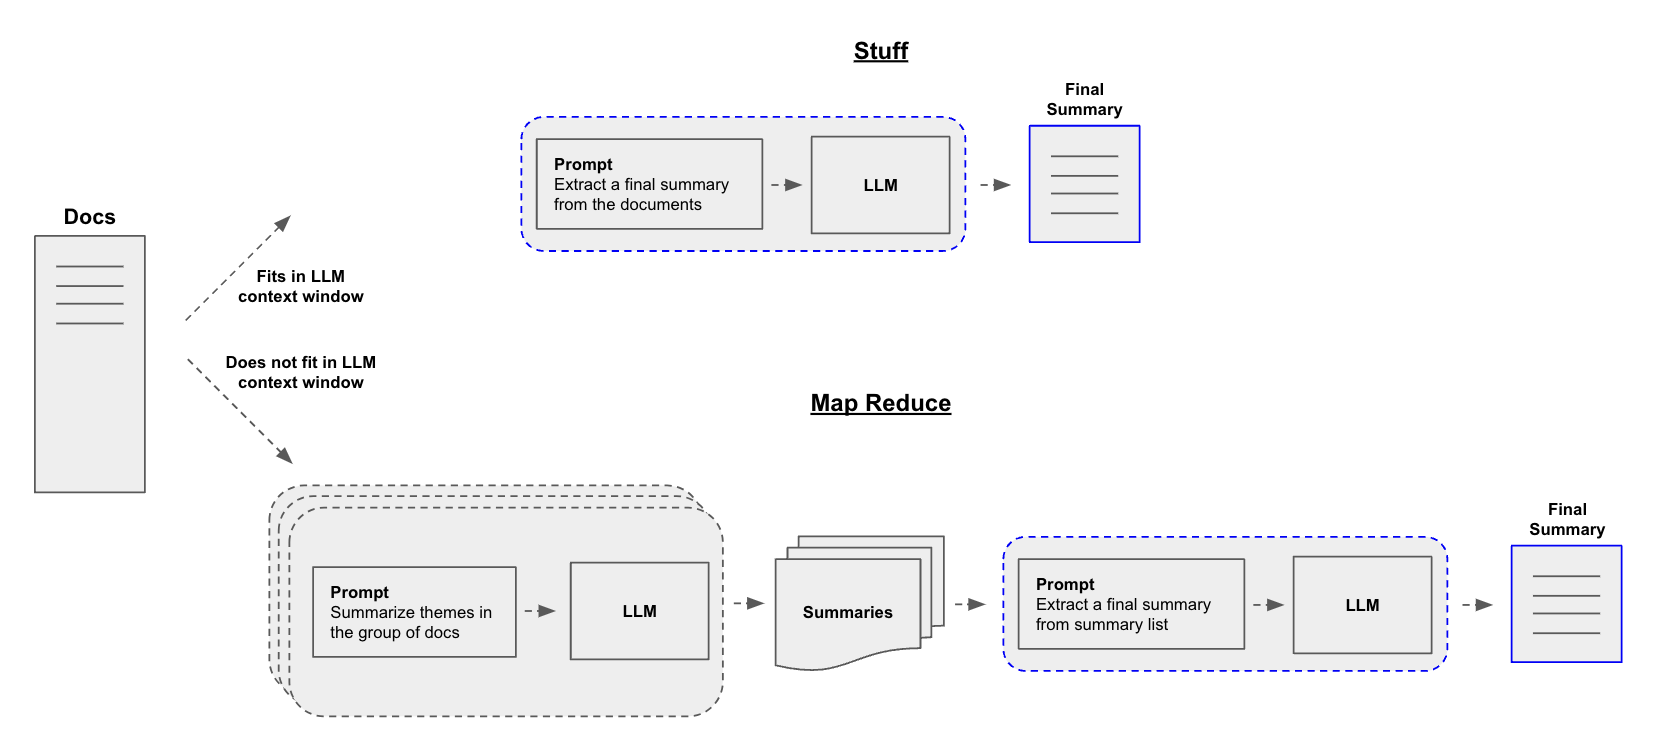

## Stuff Document Chain text summarization

In [15]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("I Have A Dream Speech.pdf")
docs = loader.load_and_split()
docs


[Document(metadata={'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': 'D:20131107152210', 'author': 'Jeffrey W. Collins', 'moddate': 'D:20131107152210', 'source': 'I Have A Dream Speech.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='Group 1: Handout \n“I Have a Dream Speech” – Dr. Martin Luther King, Jr. \nSource: http://www.freemaninstitute.com/Dream.htm  \nAugust 28, 1963 --  \nI am happy to join with you today in what will go down in history as the greatest demonstration for freedom in \nthe history of our nation. \nFive score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation \nProclamation.  This momentous decree came as a great beacon light of hope to millions of Negro slaves, who \nhad been seared in the flames of withering injustice.  It came as a joyous daybreak to end the long night of their \ncaptivity. \nBut one hundred years later, the Negro still is not free

In [16]:
## for prompt template
template = """
Write a concise and precise summary of the following speech:
Speech:{text}
"""

prompt = PromptTemplate(input_variables=["text"],
                        template=template)

In [17]:
from langchain.chains.summarize import load_summarize_chain
chain = load_summarize_chain(llm, chain_type="stuff",prompt=prompt, verbose=True)

In [20]:
summary = chain.invoke(docs)
summary



> Entering new StuffDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:

Write a concise and precise summary of the following speech:
Speech:Group 1: Handout 
“I Have a Dream Speech” – Dr. Martin Luther King, Jr. 
Source: http://www.freemaninstitute.com/Dream.htm  
August 28, 1963 --  
I am happy to join with you today in what will go down in history as the greatest demonstration for freedom in 
the history of our nation. 
Five score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation 
Proclamation.  This momentous decree came as a great beacon light of hope to millions of Negro slaves, who 
had been seared in the flames of withering injustice.  It came as a joyous daybreak to end the long night of their 
captivity. 
But one hundred years later, the Negro still is not free.  One hundred years later, the life of the Negro is still 
sadly crippled by the manacles of segregation and the chains of discrimination.  

{'input_documents': [Document(metadata={'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': 'D:20131107152210', 'author': 'Jeffrey W. Collins', 'moddate': 'D:20131107152210', 'source': 'I Have A Dream Speech.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='Group 1: Handout \n“I Have a Dream Speech” – Dr. Martin Luther King, Jr. \nSource: http://www.freemaninstitute.com/Dream.htm  \nAugust 28, 1963 --  \nI am happy to join with you today in what will go down in history as the greatest demonstration for freedom in \nthe history of our nation. \nFive score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation \nProclamation.  This momentous decree came as a great beacon light of hope to millions of Negro slaves, who \nhad been seared in the flames of withering injustice.  It came as a joyous daybreak to end the long night of their \ncaptivity. \nBut one hundred years later, the Neg

## Map reduce to summarize the large documents

In [21]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [23]:
len(docs)

4

In [24]:
final_docs = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100).split_documents(docs)
final_docs


[Document(metadata={'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': 'D:20131107152210', 'author': 'Jeffrey W. Collins', 'moddate': 'D:20131107152210', 'source': 'I Have A Dream Speech.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='Group 1: Handout \n“I Have a Dream Speech” – Dr. Martin Luther King, Jr. \nSource: http://www.freemaninstitute.com/Dream.htm  \nAugust 28, 1963 --  \nI am happy to join with you today in what will go down in history as the greatest demonstration for freedom in \nthe history of our nation. \nFive score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation \nProclamation.  This momentous decree came as a great beacon light of hope to millions of Negro slaves, who \nhad been seared in the flames of withering injustice.  It came as a joyous daybreak to end the long night of their \ncaptivity. \nBut one hundred years later, the Negro still is not free

In [25]:
len(final_docs)

13

In [33]:
## prompt and prompt template for the chunks of documents
chunk_prompt = """
Give the summary of the given speech:
Speech:{text}
Summary:
"""
map_reduce_template = PromptTemplate(input_variables=['text'],template=chunk_prompt)


In [35]:

final_prompt='''
Provide the final summary of the entire speech with these important points.
Add a Motivation Title. Start the precise summary with an introduction and provide the summary in number points for the speech.
Speech:{text}

'''
final_prompt_template = PromptTemplate(input_variables=["text"],
                                      template=final_prompt)


In [36]:
summary_chain = load_summarize_chain(
    llm=llm,
    chain_type="map_reduce",
    map_prompt = map_reduce_template,
    combine_prompt = final_prompt_template,
    verbose=True
)

In [39]:
final_summary = summary_chain.run(final_docs)
final_summary



> Entering new MapReduceDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:

Give the summary of the given speech:
Speech:Group 1: Handout 
“I Have a Dream Speech” – Dr. Martin Luther King, Jr. 
Source: http://www.freemaninstitute.com/Dream.htm  
August 28, 1963 --  
I am happy to join with you today in what will go down in history as the greatest demonstration for freedom in 
the history of our nation. 
Five score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation 
Proclamation.  This momentous decree came as a great beacon light of hope to millions of Negro slaves, who 
had been seared in the flames of withering injustice.  It came as a joyous daybreak to end the long night of their 
captivity. 
But one hundred years later, the Negro still is not free.  One hundred years later, the life of the Negro is still 
sadly crippled by the manacles of segregation and the chains of discrimination.  One hundred years l

'**Motivation Title:** "Dreaming of a Brighter Future: A Call to Action for Freedom and Equality"\n\n**Summary:**\n\nHere are the key points from Dr. Martin Luther King Jr.\'s "I Have a Dream" speech:\n\n1. **Introduction**: The speech begins by referencing the Emancipation Proclamation, which did not fully free African Americans, and highlights the ongoing struggle for freedom and equality.\n2. **The Struggle is Real**: The speaker notes that despite the promises of freedom and equality enshrined in the Constitution and Declaration of Independence, African Americans are still marginalized and excluded from full participation in society.\n3. **A Call to Action**: The speech emphasizes the importance of making justice a reality for all people, regardless of their race or background, and urges immediate action to achieve this goal.\n4. **Non-Violent Resistance**: The speaker advocates for non-violent resistance, encouraging the use of "soul force" to overcome physical force, and emphasiz

## Refine Chain for text summarization  
The refine documents chain constructs a response by looping over the input documents and iteratively updating its answer. For each document, it passes all non-document inputs, the current document, and the latest intermediate answer to an LLM chain to get a new answer.

In [40]:
refine_chain = load_summarize_chain(
    llm=llm,
    chain_type="refine",
    verbose=True
)

In [41]:
output_summary = refine_chain.run(final_docs)
output_summary



> Entering new RefineDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
Write a concise summary of the following:


"Group 1: Handout 
“I Have a Dream Speech” – Dr. Martin Luther King, Jr. 
Source: http://www.freemaninstitute.com/Dream.htm  
August 28, 1963 --  
I am happy to join with you today in what will go down in history as the greatest demonstration for freedom in 
the history of our nation. 
Five score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation 
Proclamation.  This momentous decree came as a great beacon light of hope to millions of Negro slaves, who 
had been seared in the flames of withering injustice.  It came as a joyous daybreak to end the long night of their 
captivity. 
But one hundred years later, the Negro still is not free.  One hundred years later, the life of the Negro is still 
sadly crippled by the manacles of segregation and the chains of discrimination.  One hundred years later

'Based on the additional context, I refined the original summary to provide an even more comprehensive overview of Dr. Martin Luther King Jr.\'s "I Have a Dream" speech:\n\nDr. Martin Luther King Jr.\'s iconic "I Have a Dream" speech, delivered on August 28, 1963, commemorates the 100th anniversary of the Emancipation Proclamation, which declared freedom for slaves. However, King notes that despite this progress, African Americans are still not fully free, suffering from segregation, discrimination, and poverty. He emphasizes that the nation has defaulted on its promise of equality and justice, leaving African Americans with a "bad check" that has "come back marked \'insufficient funds\'".\n\nKing urges his fellow marchers to maintain dignity and discipline in the struggle for freedom, warning against seeking satisfaction through bitterness and hatred. He stresses the importance of using creative protest to bring about change, rather than resorting to physical violence. King also ackno